In [52]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection

In [7]:
t = sp.symbols("t")

In [8]:
x_expr = sp.sin(3 * t)
y_expr = sp.sin(4 * t)

In [9]:
x_func = sp.lambdify(t, x_expr, "numpy")
y_func = sp.lambdify(t, y_expr, "numpy")


In [10]:
t_vals = np.linspace(0, 2*np.pi, 5000)

In [11]:
x_vals = x_func(t_vals)
y_vals = y_func(t_vals)

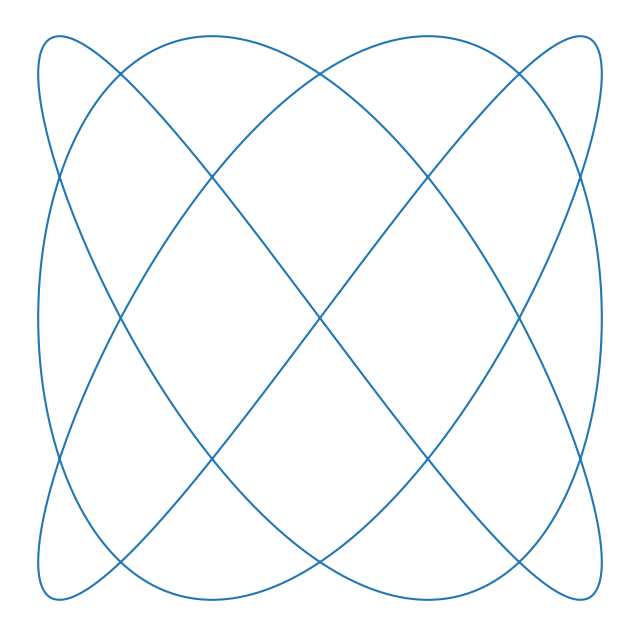

In [12]:
plt.figure(figsize=(8, 8))

plt.plot(x_vals, y_vals)

plt.axis("equal")
plt.axis("off")
plt.show()

### Adding color

/var/folders/0j/td5k7pfs7hx1bz80_nl6hggm0000gn/T/ipykernel_49006/1724429307.py:3: RuntimeWarning: invalid value encountered in sqrt
  x = np.sqrt(np.cos(5*t))
/var/folders/0j/td5k7pfs7hx1bz80_nl6hggm0000gn/T/ipykernel_49006/1724429307.py:4: RuntimeWarning: invalid value encountered in sqrt
  y = np.sqrt(np.sin(4*t))
/var/folders/0j/td5k7pfs7hx1bz80_nl6hggm0000gn/T/ipykernel_49006/1724429307.py:22: RuntimeWarning: invalid value encountered in sqrt
  x = -np.sqrt(np.cos(5*t))
/var/folders/0j/td5k7pfs7hx1bz80_nl6hggm0000gn/T/ipykernel_49006/1724429307.py:23: RuntimeWarning: invalid value encountered in sqrt
  y = np.sqrt(np.sin(4*t))


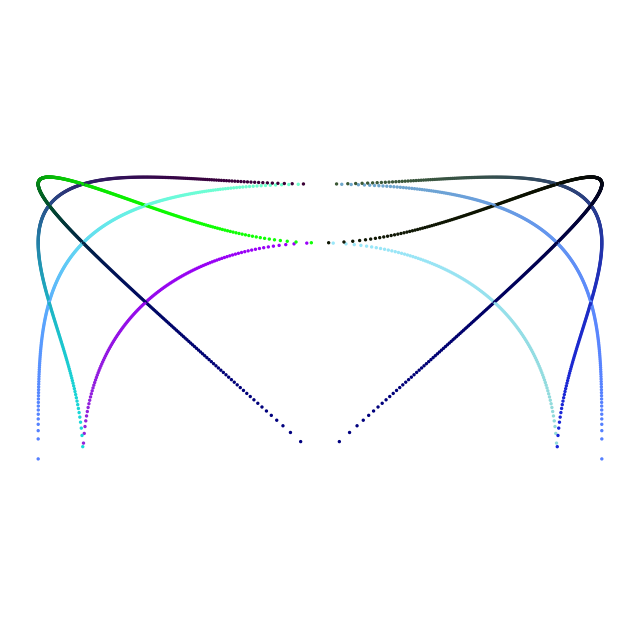

In [45]:
t = np.linspace(0, 10*np.pi, 5000)

x = np.sqrt(np.cos(5*t))
y = np.sqrt(np.sin(4*t))

r = (np.sin(t) + 1) / 3
g = (np.sin(t) + 1) / 2
b = (np.cos(3*t) + 1) / 2

colors = np.column_stack((r, g, b))

plt.figure(figsize=(8, 8))

plt.scatter(
    x,
    y,
    c=colors,
    s=2
)

# If I negate the x, it flips the image
x = -np.sqrt(np.cos(5*t))
y = np.sqrt(np.sin(4*t))

r = (np.sin(t) + 1) / 3
g = (np.sin(5*t) + 1) / 2
b = (np.cos(3*t) + 1) / 2

colors = np.column_stack((r, g, b))

plt.scatter(
    x,
    y,
    c=colors,
    s=2
)

plt.axis("equal")
plt.axis("off")
plt.show()

### Trying looping with circles

In [ ]:
# Parameter values
t = np.linspace(0, 8 * np.pi, 1000)

# Circle center equations
x = np.sin(3 * t)
y = np.sin(4 * t)

# Dynamic radius
#radius = 0.02 + 0.015 * ((np.sin(5 * t) + 1) / 2)

# Dynamic RGB values, all kept between 0 and 1
r = (np.sin(t) + 1) / 2
g = (np.sin(2 * t) + 1) / 2
b = (np.cos(3 * t) + 1) / 2

fig, ax = plt.subplots(figsize=(100, 100))

for i in range(len(t)):
    color = (0, 0, 0)

    circle = Circle(
        (x[i], y[i]),
        radius=0.01,
        facecolor='white',
        edgecolor="black"
    )

    ax.add_patch(circle)

ax.set_aspect("equal")
ax.set_xlim(x.min() - 0.1, x.max() + 0.1)
ax.set_ylim(y.min() - 0.1, y.max() + 0.1)
ax.axis("off")

plt.show()

### Starting to try and make my own drawing

https://www.theguardian.com/science/alexs-adventures-in-numberland/2015/feb/24/catch-of-the-day-mathematician-nets-weird-complex-fish

In [117]:
def make_shape(a = 2, b = 3, c = 3, d = 1, N = 100):

    t = np.linspace(0, 100, N)
    fig, ax = plt.subplots(figsize=(12, 8))

    # Point P(t)
    x1 = -2.2 * np.cos(2 * a * np.pi * t / 100)
    y1 =  0.6 * np.sin(2 * b * np.pi * t / 100) ** 3

    x2 =  0.5 * np.sin(2 * c * np.pi * t / 100)
    y2 =  1.1 * np.cos(2 * d * np.pi * t / 100)

    # Each row describes one line:
    # [(x1,y1), (x2,y2)]
    segments = np.stack(
        [
            np.column_stack((x1, y1)),
            np.column_stack((x2, y2))
        ],
        axis=1
    )


    collection = LineCollection(
        segments,
        linewidths=0.25, 
        colors = 'blue'
    )

    ax.add_collection(collection)

    ax.autoscale()
    
    ax.set_aspect("equal")
    ax.axis("off")


    plt.show()
    print(str(a)+ " " + str(b)+ " " + str(c)+ " " + str(d))
    # fig.savefig(
    #     "fish.png",
    #     dpi=300,
    #     bbox_inches="tight"
    # )

    # plt.close(fig)

#### Integers that I want to keep track of:
Make sure to also put what the x and y currently are


--- I wonder if this can be make into a wave:
0 0 2026 4

    x1 = -3 * np.cos(2 * a * np.pi * t / 100)

    y1 = 0.25 * np.cos(2 * b * np.pi * t / 100)

--- Any values

    # Point P(t)
    x1 = -2 * np.log(2 * a * np.pi * t / 100)
    y1 = 0.5 * np.log(2 * b * np.pi * t / 100)

    # Point Q(t)
    x2 = -(2 / 25) * np.log(2 * c * np.pi * t / 10)
    y2 = (4 / 5) * np.log(2 * d * np.pi * t / 100)

-- If the above is changes to sqrt or square then it is just traingles



--- Pyramid type shapes

    # Point P(t)
    x1 = -2 * np.cos(np.log((2 * a * np.pi * t / 100)))
    y1 = 0.5 * np.square(np.sin((2 * b * np.pi * t / 100)))

    # Point Q(t)
    x2 = -(2 / 25) * np.cos(np.log(2 * c * np.pi * t / 10))
    y2 = (4 / 5) * np.square(np.sin(2 * d * np.pi * t / 100))

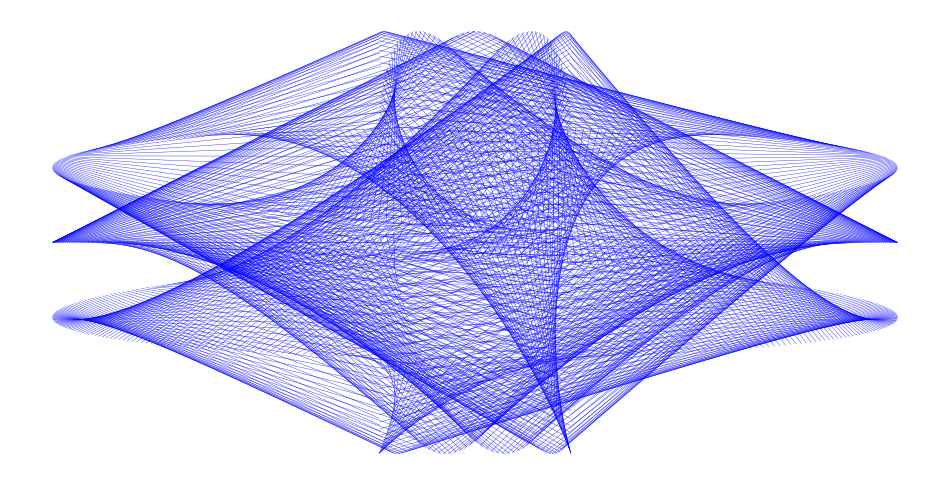

3 1 9 10


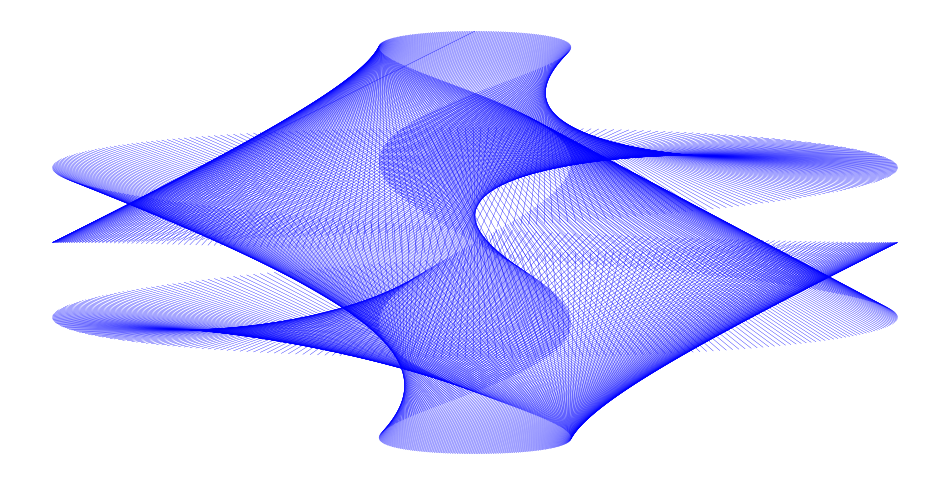

3 1 4 1


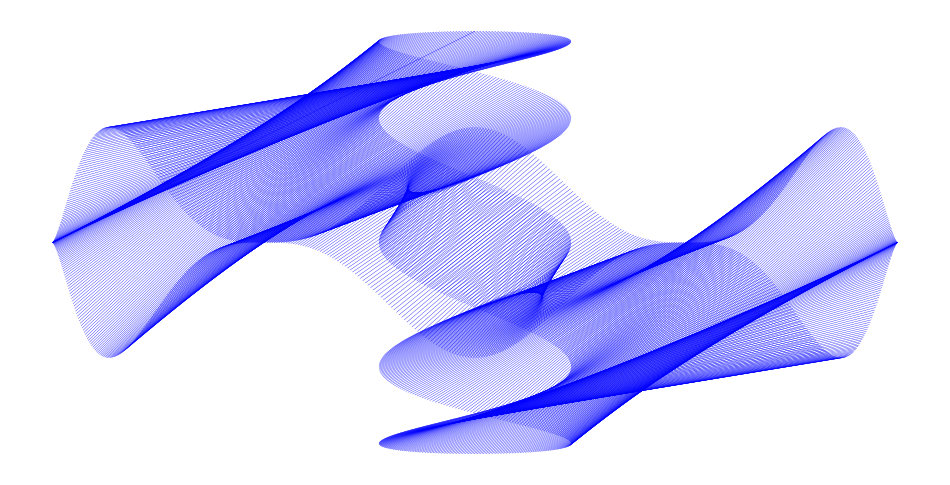

1 3 5 1


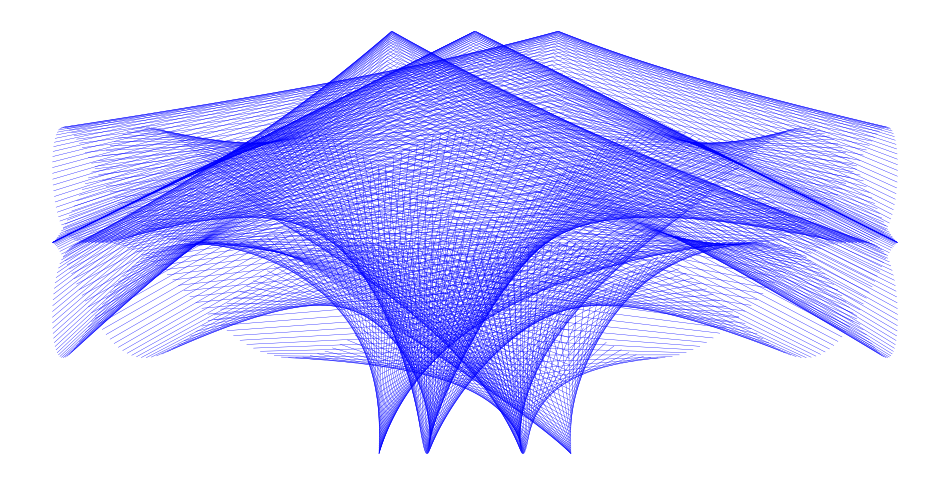

3 7 1 6


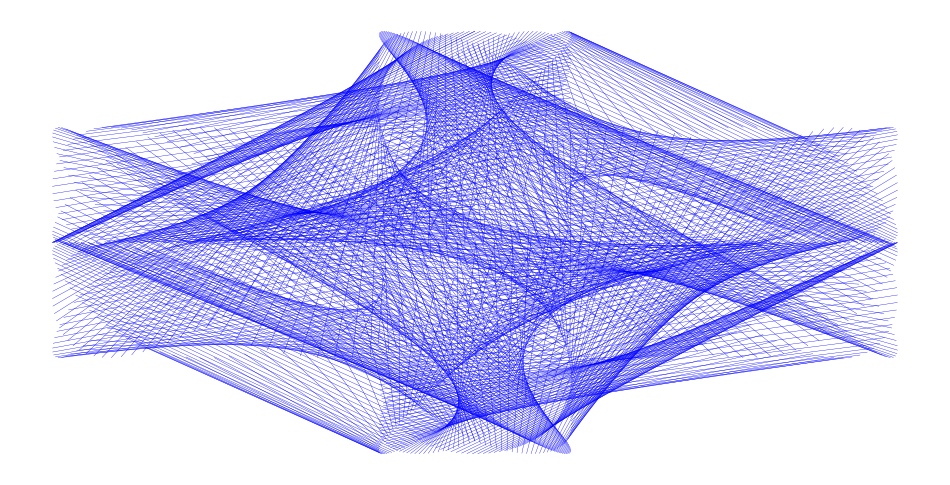

7 9 9 5


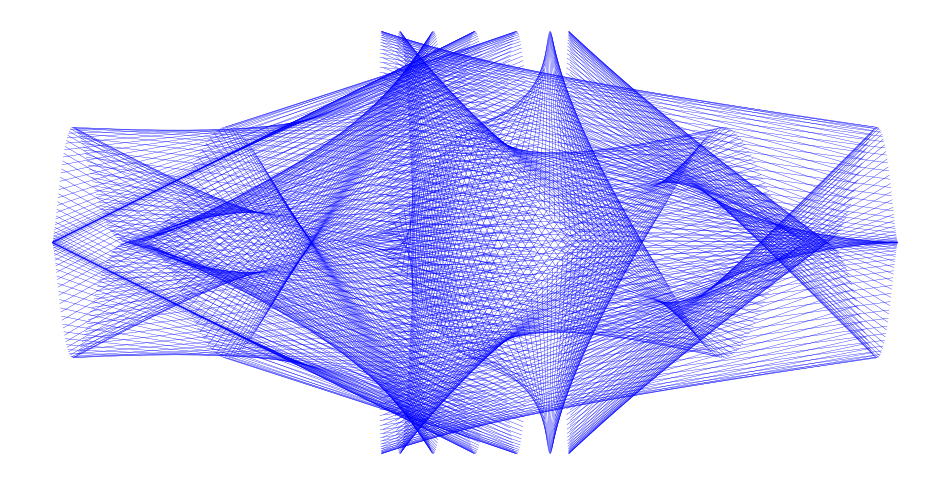

2 10 1 7


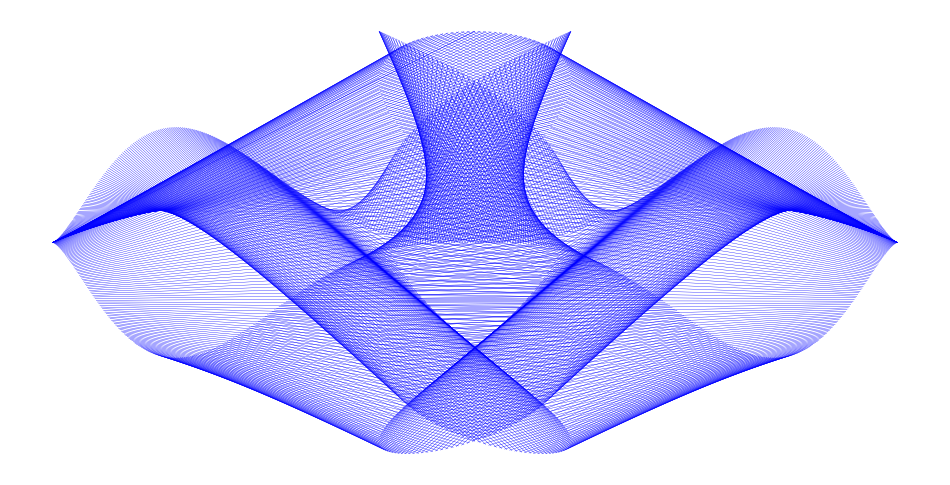

1 2 9 4


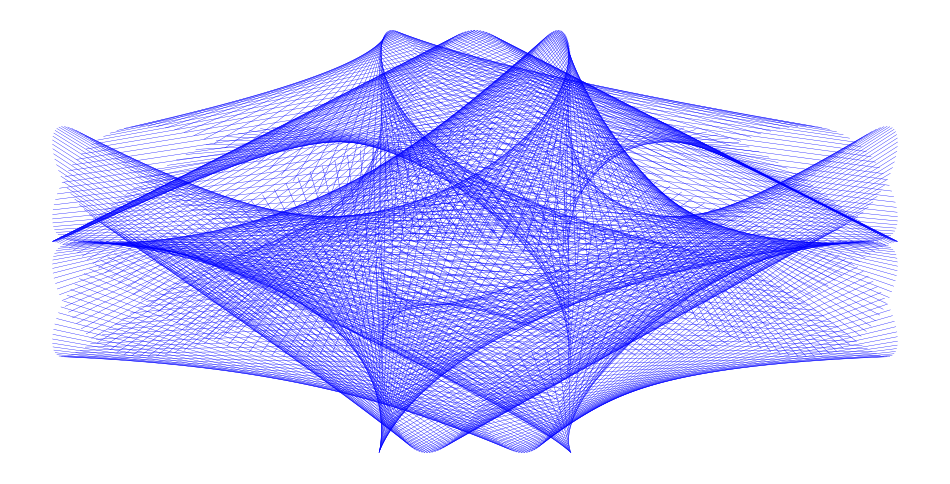

5 7 5 6


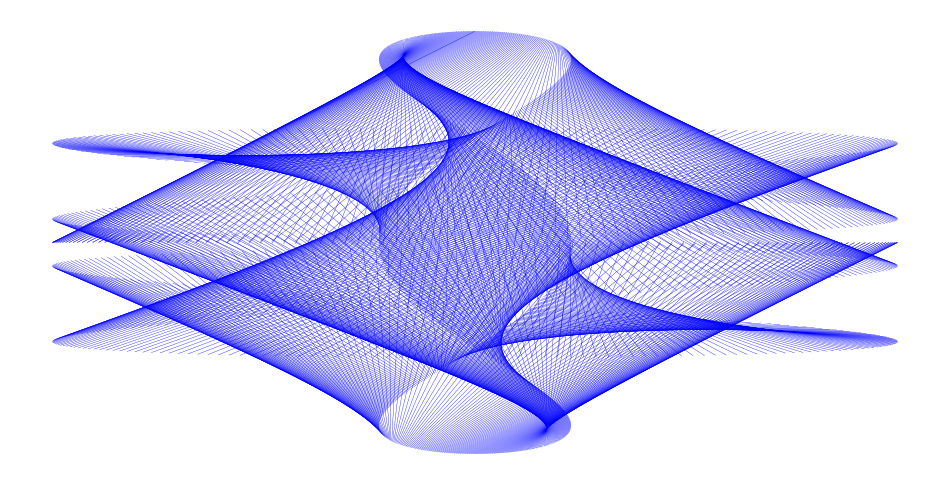

5 1 3 1


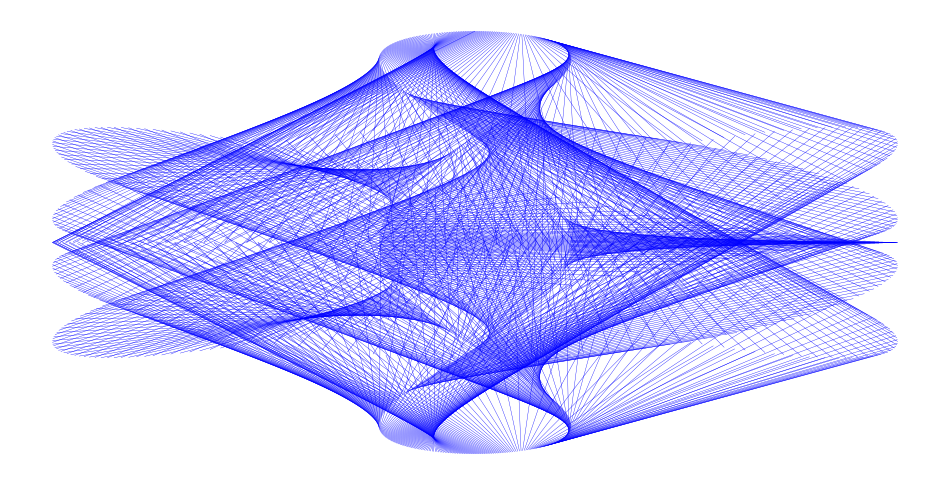

10 6 3 1


In [119]:
# Trying to find interesting shapes
import random
for i in range(10):
    a = random.randint(0, 10)
    b = random.randint(0, 10)
    c = random.randint(0, 10)
    d = random.randint(0, 10)

    make_shape(a, b, c, d, 1000)

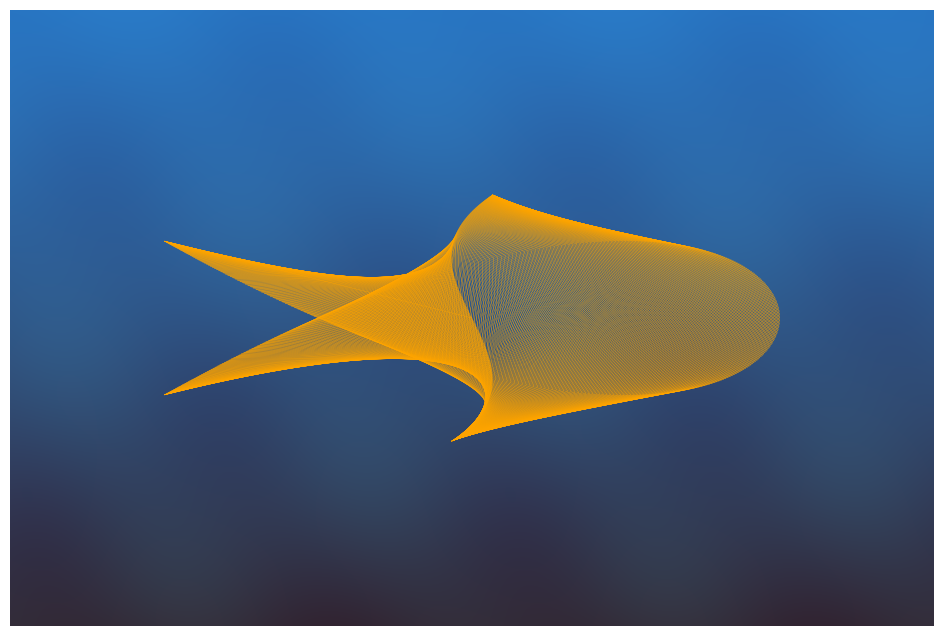

2 3 3 1


In [178]:
fig, ax = plt.subplots(figsize=(12, 8))

# Background coordinate grid
x_bg = np.linspace(-3, 3, 2000)
y_bg = np.linspace(-2, 2, 2000)

X, Y = np.meshgrid(x_bg, y_bg)

# Depth: 0 at bottom, 1 at top
depth = (Y - Y.min()) / (Y.max() - Y.min())

# Mathematical light / water texture
waves = (
    0.05 * np.sin(4 * X + 2 * Y)
    + 0.04 * np.sin(2 * X - 3 * Y)
)

# RGB fields
R = 0.2 + 0.07 * np.sin(depth + waves) - 0.1 * depth
G = 0.17 + 0.35 * np.sin(depth + waves)
B = 0.22 + 0.65 * np.sin(depth + 0.5 * waves)

background = np.dstack([
    np.clip(R, 0, 1),
    np.clip(G, 0, 1),
    np.clip(B, 0, 1)
])

ax.imshow(
    background,
    extent=[-3, 3, -2, 2],
    origin="lower",
    aspect="auto"
)
make_shape()

In [10]:
1/0

ZeroDivisionError: division by zero

### Trying to mimic an example from Hamid Naderi

His bird, shown here: https://www.ams.org/publicoutreach/math-imagery/yeganeh


In [179]:
# Parameter values
k = np.arange(1, 9831)

# Circle center equations
x = (
    np.sin(np.pi * k / 20000) ** 12
    * (
        0.5
        * np.cos(31 * np.pi * k / 10000) ** 16
        * np.sin(6 * np.pi * k / 10000)
        +
        (1/6 * np.sin(31 * np.pi * k / 10000)) ** 20
    )
    +
    3 * k / 20000
    +
    np.cos(31 * np.pi * k / 10000) ** 6
    * np.sin(
        (np.pi / 2)
        * ((k - 10000) / 10000) ** 7
        - np.pi / 5
    )
)
y = (
    (-9 / 4)
    * np.cos(31 * np.pi * k / 10000) ** 6
    * np.cos(
        (np.pi / 2)
        * ((k - 10000) / 10000) ** 7
        - np.pi / 5
    )
    * (
        (2 / 3)
        +
        (
            np.sin(np.pi * k / 20000)
            * np.sin(3 * np.pi * k / 20000)
        ) ** 6
    )
    +
    (3 / 4)
    * np.cos(3 * np.pi * (k - 10000) / 100000) ** 10
    * np.cos(9 * np.pi * (k - 10000) / 100000) ** 10
    * np.cos(36 * np.pi * (k - 10000) / 100000) ** 14
    +
    (7 / 10)
    * ((k - 10000) / 10000) ** 2
)
radius = (
    np.sin(np.pi * k / 20000) ** 10
    * (
        (1 / 4)
        * np.cos(
            31 * np.pi * k / 10000
            + 25 * np.pi / 32
        ) ** 20
        +
        (1 / 20)
        * np.cos(31 * np.pi * k / 10000) ** 2
    )
    +
    (1 / 30)
    * (
        (3 / 2)
        -
        np.cos(62 * np.pi * k / 10000) ** 2
    )
)

# Dynamic radius
#radius = 0.02 + 0.015 * ((np.sin(5 * t) + 1) / 2)

# Dynamic RGB values, all kept between 0 and 1
r = (np.sin(t) + 1) / 2
g = (np.sin(2 * t) + 1) / 2
b = (np.cos(3 * t) + 1) / 2

fig, ax = plt.subplots(figsize=(10000, 10000))

for i in range(9831):
    color = (0, 0, 0)

    circle = Circle(
        (x[i], y[i]),
        radius=radius[i],
        facecolor='white',
        edgecolor="black"
    )

    ax.add_patch(circle)

ax.set_aspect("equal")
ax.set_xlim(x.min() - 0.1, x.max() + 0.1)
ax.set_ylim(y.min() - 0.1, y.max() + 0.1)
ax.axis("off")

plt.savefig(
    "bird.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

: 